
# 01 &nbsp;|&nbsp; Data Ingestion, Profiling and Quality Audit

**Dissertation:** *Temporal Prediction of In-Trial Adverse Events in Oncology Clinical Trials Using Machine Learning*
**Student:** Thakar Manan Pradipbhai (2024DA04324) — M.Tech. Data Science & Engineering, BITS Pilani
**Supervisor:** Kishor Gund, Principal Consultant, Jade Global Software Pvt. Ltd. — Pune

---

## Purpose of this notebook

This notebook executes **Phase 3 (Baseline Dataset Blueprint and Feature Mapping)** and the
audit half of **Phase 4 (Static Dataset Construction and Data Quality Audit)** from the
mid-semester plan. Concretely it:

1. loads the Project Data Sphere SAS transport files for study **A6181122**;
2. reconciles them against the study data dictionary (`A6181122_SPECS.xlsx`);
3. identifies the patient identifier, the date/day fields and the adverse-event grade
   field required for label construction;
4. derives the **per-patient observation window** on which every later label depends;
5. runs an explicit, reproducible data-quality audit.

## The dataset

| Item | Value |
|---|---|
| Protocol | **A6181122** |
| Design | Randomised, double-blind Phase III |
| Population | Metastatic **colorectal cancer**, second line |
| Regimen | FOLFIRI (irinotecan + 5-fluorouracil + leucovorin) ± sunitinib |
| Released arm | **Comparator arm only** — FOLFIRI + placebo |
| Patients | 379 |
| Time origin | Study day 1 = first dose of study treatment |

> **Note on the arm.** Project Data Sphere releases the *comparator* arm of sponsor
> trials. Every patient in this download therefore received FOLFIRI + placebo. This is
> methodologically convenient — treatment assignment is constant, so it cannot confound
> the toxicity model — but it also means no treatment-arm contrast can be studied.

In [ ]:
# --- environment setup -------------------------------------------------------
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aeprep import io, quality, labels, features_static, features_temporal
from aeprep import modeling, evaluation, plots
from aeprep.config import CFG, DATASET_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR, ensure_output_dirs

ensure_output_dirs()
plots.set_style()
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print(f"project root : {PROJECT_ROOT}")
print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"analysis config: horizon={CFG.prediction_horizon_days}d, "
      f"grade>={CFG.severity_threshold}, landmark step={CFG.landmark_step_days}d")

project root : C:\BITS M Tech\Sem 4 Dissertation\Sem 4 Dissertation\ProjectWork\project-root
pandas 2.3.3 | numpy 2.3.5
analysis config: horizon=30d, grade>=3, landmark step=14d



## 1. Which domains were actually downloaded?

The SPECS workbook describes every domain the sponsor curated for this study. The download
in `data-files/` is a subset. Establishing the gap up front is important because it
determines which feature families are available for modelling.

In [ ]:
domains = io.load_all_domains()
availability = io.available_domains()

specs = io.load_specs()
specs_domains = sorted(specs["DOMAIN"].str.lower().unique())

avail_tbl = pd.DataFrame({
    "domain": list(availability),
    "downloaded": list(availability.values()),
})
avail_tbl["in_specs"] = avail_tbl["domain"].isin(specs_domains)
avail_tbl["n_rows"] = avail_tbl["domain"].map(
    {k: len(v) for k, v in domains.items()}).fillna(0).astype(int)
avail_tbl["role"] = avail_tbl["domain"].map({
    "adverse":  "TARGET - AE term, CTCAE grade, start/stop day, action taken",
    "demog":    "baseline demographics",
    "testdrug": "study-treatment dosing (longitudinal)",
    "vitals":   "vital signs (longitudinal)",
    "pfm_p":    "ECOG performance status (longitudinal)",
    "final":    "disposition / end of treatment / end of study",
    "random":   "randomisation day",
    "primdiag": "primary diagnosis",
    "prevdis":  "medical history",
    "condrug":  "concomitant medication (longitudinal)",
    "contrt":   "concomitant non-drug treatment",
    "phyexam":  "physical examination (longitudinal)",
    "lab_safe": "SAFETY LABORATORY RESULTS - haematology + chemistry, with normal ranges",
    "iota_p":   "overall RECIST tumour response, longitudinal",
    "tmm_p":    "target lesion measurements (tumour burden), longitudinal",
    "cd_b_p":   "prior systemic anti-cancer therapy",
    "cn_6_p":   "prior radiotherapy",
    "ecg":      "ECG - described in SPECS, still not downloaded",
}).fillna("")
avail_tbl

,domain,downloaded,in_specs,n_rows,role
0,adverse,True,True,6166,"TARGET - AE term, CTCAE grade, start/stop day,..."
1,demog,True,True,379,baseline demographics
2,testdrug,True,True,26283,study-treatment dosing (longitudinal)
3,vitals,True,True,6653,vital signs (longitudinal)
4,pfm_p,True,True,3213,ECOG performance status (longitudinal)
5,final,True,True,1137,disposition / end of treatment / end of study
6,random,True,True,379,randomisation day
7,primdiag,True,True,379,primary diagnosis
8,prevdis,True,True,1399,medical history
9,condrug,True,True,13504,concomitant medication (longitudinal)



### The safety laboratory domain

`LAB_SAFE` (haematology and chemistry results, each carrying its own laboratory reference
range) is **present in this download**. It matters more than any other domain: the dominant
severe toxicity of a FOLFIRI regimen is **neutropenia**, which is *defined* by an absolute
neutrophil count, and neutropenia alone accounts for 210 of the 655 Grade ≥3 events.

An earlier round of this analysis was run before the domain was obtained, and had to infer
myelosuppression indirectly — from prior graded events, growth-factor use, dose reductions
and weight trajectory. Section 7.5 below profiles the domain; notebook 04 turns it into a
feature block. Because `io.load_all_domains()` auto-detects whichever domains are physically
present, adding it required no change to the pipeline's structure.

A third round then added four further domains: `TMM_P` and `IOTA_P` (tumour burden and RECIST response, both longitudinal), `CD_B_P` (prior systemic therapy) and `CN_6_P` (prior radiotherapy). Section 6.5 of notebook 03 shows where they earn their place — the pre-enrolment check — and Section 3 of notebook 05 shows where they do not. `ECG` remains documented in the SPECS but absent, and is not used.


In [ ]:
missing_domains = avail_tbl.query("in_specs and not downloaded")["domain"].tolist()
print("Documented in SPECS but not downloaded:", missing_domains)
print("Safety laboratory domain present:", availability["lab_safe"])

# Variables the study defines for the laboratory domain.
specs[specs["DOMAIN"].str.lower().eq("lab_safe")][["NAME", "TYPE", "LABEL"]]


Documented in SPECS but not downloaded: ['ecg']
Safety laboratory domain present: True


,NAME,TYPE,LABEL
123,COLLDAY,NUM,Day of Collection
124,CPEVENT,CHAR,CPE Name
125,LABUNITR,CHAR,Units for raw laboratory test
126,LABVALUE,CHAR,Raw textual value of result
127,LBTEST,CHAR,Laboatory Test Name
128,MAX_NORM,NUM,Maximum normal range value
129,MIN_NORM,NUM,Minimum normal range value
130,PID_A,CHAR,PID
131,PROTNO,CHAR,PROTOCOL ID
132,TESTTIME,NUM,Collection time



## 2. Data dictionary

`A6181122_SPECS.xlsx` is the authoritative variable-level dictionary. The three fields the
label depends on are `ADVERSE.AEGRADE` (CTCAE grade), `ADVERSE.AEFDAY` (start day) and
`ADVERSE.PID_A` (subject identifier).

In [ ]:
key_vars = specs[specs["NAME"].isin(
    ["PID_A", "AEGRADE", "AEFDAY", "AETDAY", "AESERC", "PREFTEXT",
     "DOSTOT", "FROMDAY", "TODAY", "DRGNAME", "PFMECOG", "EFDAY",
     "WDRLDAY", "FINSTATC", "CPEVENT"])]
key_vars[["DOMAIN", "NAME", "TYPE", "LABEL"]].reset_index(drop=True)

,DOMAIN,NAME,TYPE,LABEL
0,ADVERSE,AEFDAY,NUM,AE Start Day
1,ADVERSE,AEGRADE,NUM,CTC AE Grade Studies Collecting NCI-CTC
2,ADVERSE,AESERC,CHAR,Seriousness of AE
3,ADVERSE,AETDAY,NUM,AE Stop Day
4,ADVERSE,CPEVENT,CHAR,CPE Name
5,ADVERSE,PID_A,CHAR,PID
6,ADVERSE,PREFTEXT,CHAR,Preferred Term Text
7,CD_B_P,CPEVENT,CHAR,CPE Name
8,CD_B_P,PID_A,CHAR,PID
9,CN_6_P,CPEVENT,CHAR,CPE Name



## 3. Domain overview

`PID_A` concatenates the protocol number with a right-aligned subject number
(`'A6181122    1'`). `io.read_domain()` normalises it into a zero-padded `PID`
(`'0001'`) so joins are cheap and sorting is numeric.

In [ ]:
overview = quality.domain_overview(domains)
overview

,domain,n_rows,n_columns,n_patients,n_empty_columns,n_usable_columns,rows_per_patient
0,lab_safe,214770,11,379,1,10,566.6800
1,testdrug,26283,9,379,1,8,69.3500
2,tmm_p,13624,15,379,1,14,35.9500
3,condrug,13504,13,371,3,10,36.4000
4,phyexam,10859,10,379,1,9,28.6500
5,vitals,6653,17,379,2,15,17.5500
6,adverse,6166,31,367,9,22,16.8000
7,pfm_p,3213,6,379,0,6,8.4800
8,iota_p,2003,9,366,1,8,5.4700
9,prevdis,1399,8,379,1,7,3.6900


findfont: Failed to find font weight semibold, now using 700.


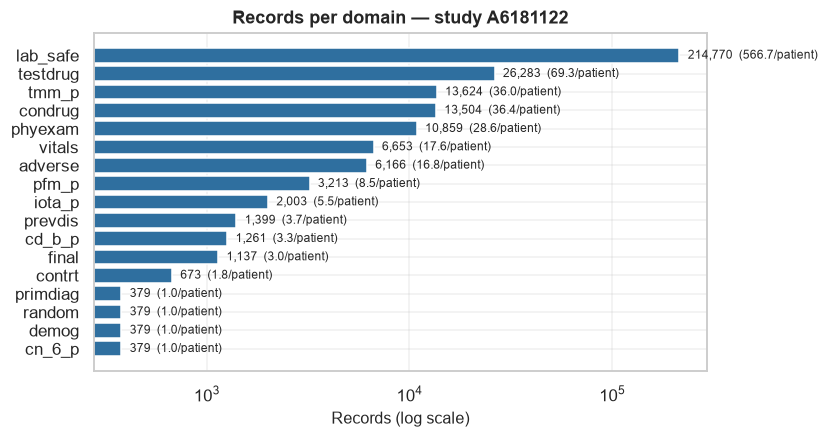

In [ ]:
overview.to_csv(TABLE_DIR / "01_domain_overview.csv", index=False)

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.barh(overview["domain"][::-1], overview["n_rows"][::-1], color=plots.PALETTE[0])
ax.set_xscale("log")
ax.set(xlabel="Records (log scale)", title="Records per domain — study A6181122")
for y, (n, p) in enumerate(zip(overview["n_rows"][::-1], overview["rows_per_patient"][::-1])):
    ax.text(n * 1.1, y, f"{n:,}  ({p:.1f}/patient)", va="center", fontsize=8)
plots.save(fig, "01_records_per_domain")
plt.show()


## 4. Column-level profile

Project Data Sphere de-identification blanks a number of fields entirely (country,
some CPE event labels, free-text causality names). Listing them explicitly documents why
they never appear as predictors.

In [ ]:
profile = quality.profile_all(domains)
profile.to_csv(TABLE_DIR / "01_column_profile.csv", index=False)
print(f"{len(profile)} columns profiled across {len(domains)} domains")

profile[profile["domain"].eq("adverse")].reset_index(drop=True)

194 columns profiled across 17 domains


,domain,column,dtype,n_rows,n_non_null,pct_missing,n_unique,example_values
0,adverse,PID,string,6166,6166,0.0000,367,"0001, 0002, 0003, 0004"
1,adverse,AEACTT,object,6166,146,97.6300,124,"REFERRED BACK TO DIABETIC DA, DOSE DELAYED, TR..."
2,adverse,AECS1NM,float64,6166,0,100.0000,0,
3,adverse,AECS2NM,float64,6166,0,100.0000,0,
4,adverse,AECS3NM,float64,6166,0,100.0000,0,
5,adverse,AEGRADE,float64,6166,6165,0.0200,5,"1.0, 3.0, 4.0, 2.0"
6,adverse,AEST1NM,object,6166,6166,0.0000,1,SUNITINIB OR PLACEBO
7,adverse,AEST2NM,object,6166,6166,0.0000,1,FOLFIRI
8,adverse,AEST3NM,float64,6166,0,100.0000,0,
9,adverse,CPEVENT,float64,6166,0,100.0000,0,


In [ ]:
empty_cols = quality.constant_or_empty_columns(domains)
print(f"{len(empty_cols)} columns carry no usable information:")
empty_cols

63 columns carry no usable information:


,domain,column,reason,value
0,adverse,AECS1NM,all missing,None
1,adverse,AECS2NM,all missing,None
2,adverse,AECS3NM,all missing,None
3,adverse,AEST1NM,single value,SUNITINIB OR PLACEBO
4,adverse,AEST2NM,single value,FOLFIRI
...,...,...,...,...
58,cd_b_p,CMDECOD,all missing,None
59,cd_b_p,NONEF,all missing,None
60,cd_b_p,ONCBRP,all missing,None
61,cn_6_p,PROTNO,single value,A6181122



## 5. Deriving the patient timeline

Every label and every risk set in this dissertation depends on four per-patient anchors:

| Anchor | Definition |
|---|---|
| `first_dose_day` | earliest `TESTDRUG.FROMDAY` — the time origin |
| `last_dose_day` | latest `TESTDRUG.TODAY` |
| `eot_day` | `FINAL.WDRLDAY` where `CPEVENT = END_OF_TREATMENT` |
| `eos_day` | `FINAL.WDRLDAY` where `CPEVENT = END_OF_STUDY` |

From these, two derived windows are constructed:

* **`ae_obs_end`** — the last day on which an adverse event could still have been
  captured, `min(eos_day, last_dose_day + 28)`, extended when events were in fact
  reported later so that no observed event is silently discarded. This bounds the
  **label** window.
* **`on_treatment_end`** — `min(eot_day, ae_obs_end)`. This bounds the **risk set**:
  a forward-looking in-trial prediction is only meaningful while the patient is still
  receiving study treatment.

In [ ]:
timeline = io.build_patient_timeline(domains)
print(f"{len(timeline)} patients")
timeline.head(8)

379 patients


,PID,first_dose_day,last_dose_day,n_dose_records,max_cycle,eot_day,discont_reason,eos_day,final_status,last_ae_day,first_ae_day,n_ae_total,ae_obs_end,on_treatment_end,died,discont_due_to_ae,treatment_duration,study_duration
0,0001,1.0000,102.0000,30,3,104.0000,ADVERSE EVENT,642.0000,OTHER,102.0000,10.0000,7.0000,130.0000,104.0000,False,True,103.0000,641.0000
1,0002,1.0000,44.0000,13,1,56.0000,SUBJECT REFUSED CONTINUED TREATMENT FOR REASON...,56.0000,SUBJECT REFUSED CONTINUED TREATMENT FOR REASON...,53.0000,2.0000,10.0000,56.0000,56.0000,False,False,55.0000,55.0000
2,0003,1.0000,248.0000,78,6,253.0000,OBJECTIVE PROGRESSION OR RELAPSE,543.0000,OTHER,277.0000,5.0000,16.0000,277.0000,253.0000,False,False,252.0000,542.0000
3,0004,1.0000,342.0000,95,8,342.0000,OBJECTIVE PROGRESSION OR RELAPSE,677.0000,OTHER,328.0000,3.0000,13.0000,370.0000,342.0000,False,False,341.0000,676.0000
4,0005,1.0000,5.0000,5,1,13.0000,ADVERSE EVENT,677.0000,OTHER,5.0000,5.0000,2.0000,33.0000,13.0000,False,True,12.0000,676.0000
5,0006,1.0000,301.0000,69,6,301.0000,OBJECTIVE PROGRESSION OR RELAPSE,645.0000,OTHER,294.0000,15.0000,12.0000,329.0000,301.0000,False,False,300.0000,644.0000
6,0007,1.0000,46.0000,13,1,60.0000,GLOBAL DETERIORATION OF HEALTH STATUS,322.0000,LOST TO FOLLOW-UP,58.0000,2.0000,8.0000,74.0000,60.0000,False,False,59.0000,321.0000
7,0008,1.0000,63.0000,18,2,121.0000,ADVERSE EVENT,638.0000,OTHER,62.0000,50.0000,5.0000,91.0000,91.0000,False,True,120.0000,637.0000


In [ ]:
timeline[["first_dose_day", "last_dose_day", "eot_day", "eos_day",
          "ae_obs_end", "on_treatment_end", "treatment_duration",
          "study_duration", "max_cycle"]].describe().T

,count,mean,std,min,25%,50%,75%,max
first_dose_day,379.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
last_dose_day,379.0000,219.5937,139.9845,4.0000,112.0000,203.0000,323.5000,599.0000
eot_day,379.0000,231.3456,140.4451,5.0000,122.0000,216.0000,333.0000,611.0000
eos_day,379.0000,425.9683,173.8383,5.0000,308.5000,464.0000,545.0000,872.0000
ae_obs_end,379.0000,246.3325,140.5897,5.0000,140.0000,228.0000,351.0000,611.0000
on_treatment_end,379.0000,230.2665,140.2896,5.0000,120.5000,212.0000,332.0000,611.0000
treatment_duration,379.0000,230.3456,140.4451,4.0000,121.0000,215.0000,332.0000,610.0000
study_duration,379.0000,424.9683,173.8383,4.0000,307.5000,463.0000,544.0000,871.0000
max_cycle,379.0000,5.3272,3.1995,1.0000,3.0000,5.0000,7.5000,15.0000


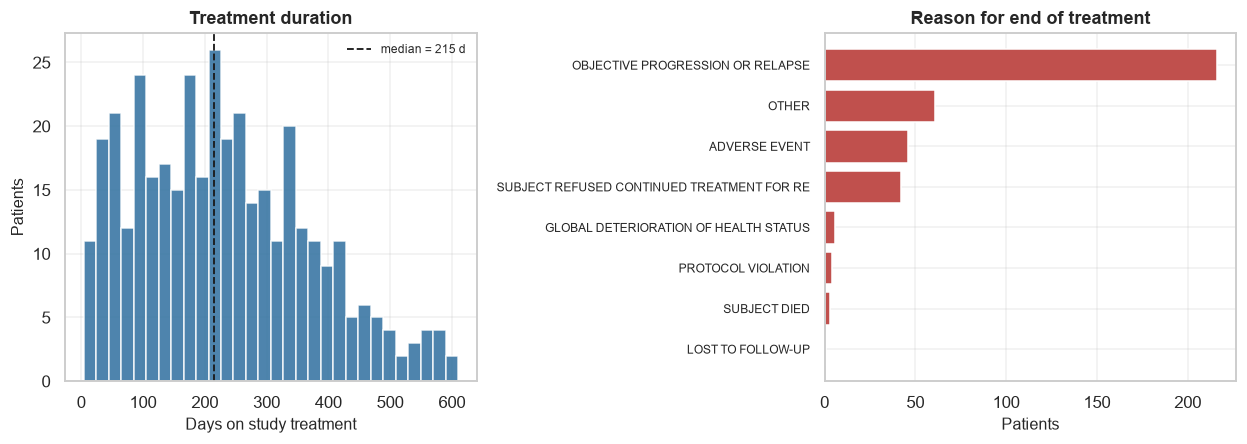

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

axes[0].hist(timeline["treatment_duration"], bins=30, color=plots.PALETTE[0], alpha=0.85)
axes[0].axvline(timeline["treatment_duration"].median(), ls="--", c="k", lw=1.2,
                label=f"median = {timeline['treatment_duration'].median():.0f} d")
axes[0].set(xlabel="Days on study treatment", ylabel="Patients",
            title="Treatment duration")
axes[0].legend(fontsize=8)

reasons = timeline["discont_reason"].fillna("Not recorded").value_counts().head(8)
axes[1].barh([r[:42] for r in reasons.index[::-1]], reasons.to_numpy()[::-1],
             color=plots.PALETTE[1])
axes[1].set(xlabel="Patients", title="Reason for end of treatment")
axes[1].tick_params(axis="y", labelsize=8)

fig.tight_layout()
plots.save(fig, "01_treatment_duration_and_discontinuation")
plt.show()


### Patients at risk over time

The risk set shrinks steadily as patients discontinue. This directly determines how far
into the trial the landmark design can go before the estimates become unstable — the
`landmark_max_day` setting in `aeprep.config`.

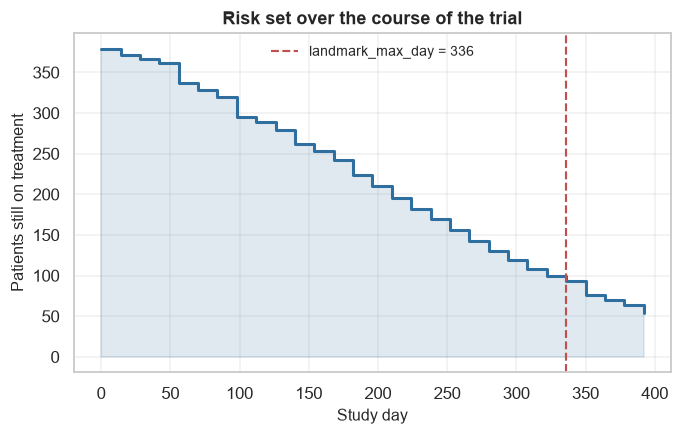

study_day,0,14,28,42,56,70,84,98,112,126,140,154,168,182,196,210,224,238,252,266,280,294,308,322,336,350,364,378,392
patients_on_treatment,379,372,367,361,337,328,320,295,289,279,262,253,242,224,210,195,182,170,156,143,130,119,108,99,93,76,70,64,54


In [ ]:
days = np.arange(0, 400, 14)
at_risk = [(timeline["on_treatment_end"] >= d).sum() for d in days]

fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.step(days, at_risk, where="post", lw=2, color=plots.PALETTE[0])
ax.axvline(CFG.landmark_max_day, ls="--", c=plots.PALETTE[1], lw=1.4,
           label=f"landmark_max_day = {CFG.landmark_max_day}")
ax.fill_between(days, at_risk, step="post", alpha=0.15, color=plots.PALETTE[0])
ax.set(xlabel="Study day", ylabel="Patients still on treatment",
       title="Risk set over the course of the trial")
ax.legend(fontsize=9)
plots.save(fig, "01_patients_at_risk")
plt.show()

pd.DataFrame({"study_day": days, "patients_on_treatment": at_risk}).set_index("study_day").T


## 6. Data-quality audit

Each check reports a record count. A non-zero count is **not automatically an error** —
clinical-trial data legitimately contains unresolved events and pre-treatment medical
history — but every one must be visible and explained rather than silently handled.

In [ ]:
checks = quality.consistency_checks(domains, timeline)
checks.to_csv(TABLE_DIR / "01_quality_checks.csv", index=False)
checks.style.hide(axis="index")

check,n_records,status,interpretation
AE with missing CTCAE grade,1,REVIEW,Ungraded events cannot contribute to the severity target.
AE with missing start day,0,OK,Start day is mandatory for windowed labelling.
AE stop day earlier than start day,0,OK,Would indicate a data-entry inversion.
AE ongoing at data cut (no stop day),818,REVIEW,Expected: unresolved events are recorded without a stop day.
AE starting before first dose,169,REVIEW,"Pre-treatment events; excluded from the target, used as baseline history."
Dosing record with missing start day,3237,REVIEW,Planned-but-not-administered cycle rows.
Dosing record with zero total dose,2053,REVIEW,Expected for the blinded placebo component and for held doses.
Patients with end-of-treatment after end-of-study,1,REVIEW,Would break the observation-window logic.
Patients with no dosing record,0,OK,Randomised but never treated.
Patients with adverse events after the derived observation end,0,OK,Should be zero by construction (window is extended to cover late events).



### Interpretation of the flagged checks

* **AE with missing CTCAE grade (1 record).** A single ungraded event cannot contribute to
  a severity-based target and is excluded from label construction.
* **AE ongoing at the data cut (818 records).** Expected. An unresolved event has no stop
  day; the temporal features exploit this by counting events *still ongoing* at each
  landmark.
* **AE starting before the first dose (169 records).** Pre-treatment findings. These are
  excluded from the target (which is *treatment-emergent* by definition) but retained as
  baseline features (`n_pretreatment_ae`, `max_pretreatment_grade`).
* **Dosing records with zero total dose.** Expected — the blinded placebo component is
  recorded with a zero dose throughout, since only the comparator arm was released.
* **AEs after the derived observation end (0 records).** Zero by construction, confirming
  that `ae_obs_end` never truncates an observed event.


## 7. Adverse-event domain — the target source

The label depends entirely on `AEGRADE` and `AEFDAY`. This section confirms both are
usable before any modelling begins.

In [ ]:
ae = io.tidy_adverse(domains["adverse"])
print(f"{len(ae):,} adverse events in {ae['PID'].nunique()} patients "
      f"({len(timeline) - ae['PID'].nunique()} patients reported none)")

grade_tbl = (ae.groupby("grade")
               .agg(n_events=("PID", "size"), n_patients=("PID", "nunique"))
               .rename_axis("CTCAE grade"))
grade_tbl["pct_events"] = (100 * grade_tbl["n_events"] / len(ae)).round(1)
grade_tbl

6,166 adverse events in 367 patients (12 patients reported none)


,n_events,n_patients,pct_events
CTCAE grade,,,
1.0000,3872,323,62.8000
2.0000,1638,323,26.6000
3.0000,525,216,8.5000
4.0000,112,80,1.8000
5.0000,18,18,0.3000


Grade >= 3: 655 events in 243 patients (64.1% of the cohort)


findfont: Failed to find font weight semibold, now using 700.


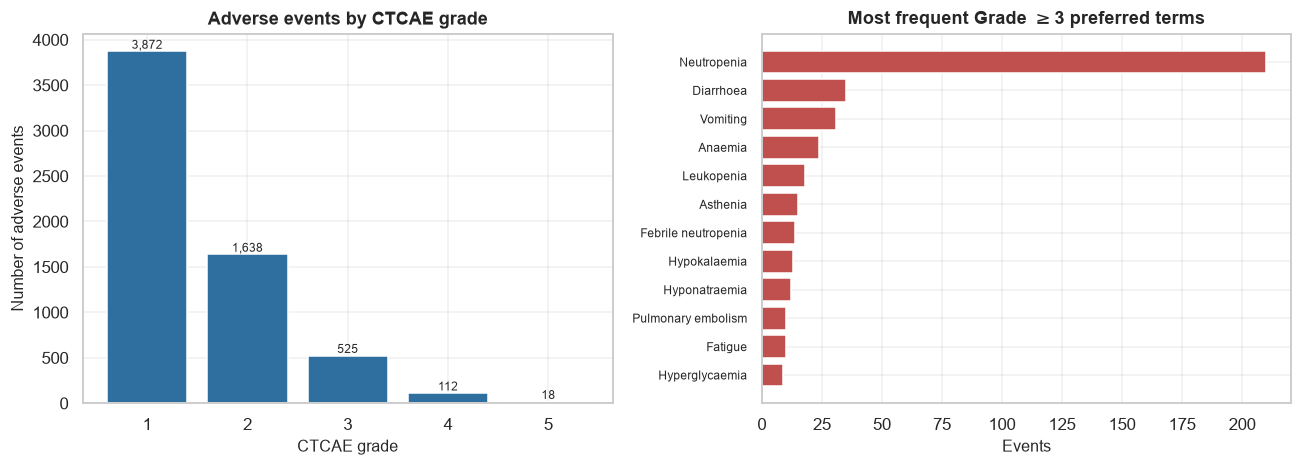

In [ ]:
severe = ae[ae["is_severe"]]
print(f"Grade >= {CFG.severity_threshold}: {len(severe):,} events "
      f"in {severe['PID'].nunique()} patients "
      f"({100 * severe['PID'].nunique() / len(timeline):.1f}% of the cohort)")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
plots.plot_ae_grade_distribution(ae, ax=axes[0])

top = severe["pt"].value_counts().head(12)[::-1]
axes[1].barh(top.index, top.to_numpy(), color=plots.PALETTE[1])
axes[1].set(xlabel="Events", title=f"Most frequent Grade $\\geq${CFG.severity_threshold} preferred terms")
axes[1].tick_params(axis="y", labelsize=8)
fig.tight_layout()
plots.save(fig, "01_ae_grade_and_top_terms")
plt.show()


Neutropenia dominates the severe events, exactly as expected for an irinotecan/5-FU
regimen — 210 of the 655 Grade ≥3 events, with the haematological cluster reaching 275.
This is precisely the toxicity that the `LAB_SAFE` domain measures directly, which is why
the next section profiles it in detail before any feature is built from it.



## 7.5 Safety laboratory domain — the direct measurement of the dominant toxicity

`LABVALUE` is stored as a **character** field mixing genuine numbers with qualitative
results (`NEGATIVE`) and explicit non-measurement markers (`ND`, `NOT DONE`). Those tokens
must become missing rather than zero, so `io.tidy_lab()` parses them explicitly.

Every record carries its own reference range (`MIN_NORM` / `MAX_NORM`) in the same units as
the result. The primary representation is therefore the dimensionless *range-relative level*

$$\text{rel} = \frac{\text{value} - \text{LLN}}{\text{ULN} - \text{LLN}}$$

which is 0 at the lower limit of normal and 1 at the upper limit. This absorbs both the unit
heterogeneity and the between-site variation in reference ranges without committing to a
single conversion table. Absolute values are additionally harmonised, because CTCAE grading
is defined on them.


In [ ]:
lab = io.tidy_lab(domains["lab_safe"])
print(f"{len(lab):,} laboratory results | {lab['PID'].nunique()} patients | "
      f"{lab['analyte'].nunique()} analytes | "
      f"{lab.groupby('PID')['day'].nunique().median():.0f} draw-days per patient (median)")

lab_profile = (lab.groupby("analyte")
                 .agg(n_results=("value", "size"),
                      n_numeric=("value", "count"),
                      n_patients=("PID", "nunique"),
                      median_rel=("rel", "median"),
                      n_graded=("ctcae", "count"))
                 .assign(pct_numeric=lambda d: (100 * d["n_numeric"] / d["n_results"]).round(1))
                 .sort_values("n_results", ascending=False))
lab_profile.to_csv(TABLE_DIR / "01_lab_profile.csv")
lab_profile


161,718 laboratory results | 379 patients | 25 analytes | 19 draw-days per patient (median)


,n_results,n_numeric,n_patients,median_rel,n_graded,pct_numeric
analyte,,,,,,
hgb,7563,7555,379,-0.0889,7555,99.9000
wbc,7514,7510,379,0.2090,7510,99.9000
plt,7512,7496,379,0.4143,7496,99.8000
anc,7244,6099,378,0.2029,6099,84.2000
mono,7165,5041,379,0.4200,0,70.4000
eos,7163,4948,378,0.2639,0,69.1000
lym,7162,5177,379,0.1851,5177,72.3000
alb,6608,6330,379,0.4000,6330,95.8000
ast,6608,6492,379,0.5312,6492,98.2000


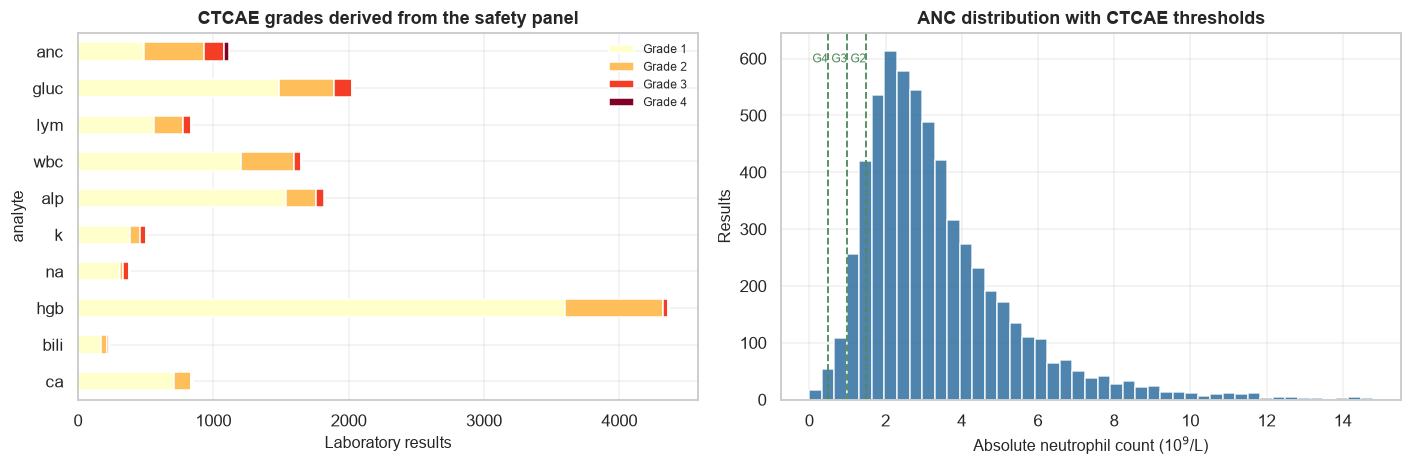

,Grade 0,Grade 1,Grade 2,Grade 3,Grade 4,Grade >=3
analyte,,,,,,
anc,4983,487,446,144,39,183
gluc,4345,1484,405,138,2,140
lym,4333,564,211,59,10,69
wbc,5852,1205,390,51,12,63
alp,4672,1539,220,59,0,59
k,5998,382,77,45,6,51
na,6143,312,19,45,5,50
hgb,3190,3602,724,36,3,39
bili,6239,173,41,16,3,19


In [ ]:
# CTCAE v3.0 grades derived from the panel, using each record's own reference range.
graded = lab[lab["ctcae"].notna()]
grade_counts = (graded.assign(g=graded["ctcae"].astype(int))
                      .pivot_table(index="analyte", columns="g", values="value",
                                   aggfunc="size").fillna(0).astype(int))
grade_counts.columns = [f"Grade {c}" for c in grade_counts.columns]
grade_counts["Grade >=3"] = grade_counts.get("Grade 3", 0) + grade_counts.get("Grade 4", 0)
grade_counts = grade_counts.sort_values("Grade >=3", ascending=False)
grade_counts.to_csv(TABLE_DIR / "01_lab_ctcae_grades.csv")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4))
top = grade_counts.head(10)[["Grade 1", "Grade 2", "Grade 3", "Grade 4"]].iloc[::-1]
top.plot(kind="barh", stacked=True, ax=axes[0], colormap="YlOrRd")
axes[0].set(xlabel="Laboratory results", title="CTCAE grades derived from the safety panel")
axes[0].legend(fontsize=8)

anc_v = lab[lab["analyte"].eq("anc")]["value"].dropna()
axes[1].hist(anc_v[anc_v < 15], bins=45, color=plots.PALETTE[0], alpha=0.85)
for thr, lbl in [(1.5, "G2"), (1.0, "G3"), (0.5, "G4")]:
    axes[1].axvline(thr, color=plots.PALETTE[2], ls="--", lw=1.2)
    axes[1].text(thr, axes[1].get_ylim()[1] * 0.92, lbl, fontsize=8,
                 color=plots.PALETTE[2], ha="right")
axes[1].set(xlabel="Absolute neutrophil count (10$^9$/L)", ylabel="Results",
            title="ANC distribution with CTCAE thresholds")
fig.tight_layout()
plots.save(fig, "01_lab_profile")
plt.show()

grade_counts


In [ ]:
# Concordance check: does a laboratory-defined severe neutropenia agree with the
# neutropenia recorded in the ADVERSE domain? Neither is a gold standard for the other,
# and the disagreement is itself informative about how the trial captured toxicity.
sev = ae[ae["is_severe"]]
neut_ae_pids = set(sev.loc[sev["pt"].str.lower().str.contains(
    "neutropenia|neutrophil count decreased", na=False), "PID"])
anc = lab[lab["analyte"].eq("anc") & lab["ctcae"].notna()]
anc_g3_pids = set(anc.loc[anc["ctcae"] >= 3, "PID"])

concordance = pd.DataFrame([
    {"source": "Grade >=3 neutropenia recorded as an adverse event",
     "n_patients": len(neut_ae_pids)},
    {"source": "Grade >=3 ANC measured in the laboratory panel",
     "n_patients": len(anc_g3_pids)},
    {"source": "Both", "n_patients": len(neut_ae_pids & anc_g3_pids)},
    {"source": "Adverse event only (nadir fell between scheduled draws)",
     "n_patients": len(neut_ae_pids - anc_g3_pids)},
    {"source": "Laboratory only (no adverse event recorded)",
     "n_patients": len(anc_g3_pids - neut_ae_pids)},
])
concordance.to_csv(TABLE_DIR / "01_lab_ae_concordance.csv", index=False)
concordance


,source,n_patients
0,Grade >=3 neutropenia recorded as an adverse e...,125
1,Grade >=3 ANC measured in the laboratory panel,96
2,Both,89
3,Adverse event only (nadir fell between schedul...,36
4,Laboratory only (no adverse event recorded),7



**Reading the concordance.** The two sources agree on the great majority of affected
patients, but neither contains the other. Scheduled draws are roughly two-weekly while the
post-FOLFIRI neutrophil nadir occurs around days 10–14, so a nadir can fall between draws
and be captured only by the clinical adverse-event record; conversely a handful of patients
have a qualifying count with no corresponding event term. This is why the laboratory block
is added *alongside* the toxicity-history block rather than replacing it.



## 8. Persist the curated artefacts

The tidied domains and the patient timeline are written to `outputs/datasets/` so that the
downstream notebooks do not have to re-parse the SAS files.

In [ ]:
timeline.to_parquet(DATASET_DIR / "patient_timeline.parquet", index=False)
io.tidy_lab(domains["lab_safe"]).to_parquet(DATASET_DIR / "lab_tidy.parquet", index=False)
io.tidy_adverse(domains["adverse"]).to_parquet(DATASET_DIR / "adverse_tidy.parquet", index=False)
io.tidy_vitals(domains["vitals"]).to_parquet(DATASET_DIR / "vitals_tidy.parquet", index=False)
io.tidy_testdrug(domains["testdrug"]).to_parquet(DATASET_DIR / "testdrug_tidy.parquet", index=False)

print("saved:")
for f in sorted(DATASET_DIR.glob("*.parquet")):
    print(f"  {f.name:32s} {f.stat().st_size / 1024:8.1f} KB")

saved:
  adverse_tidy.parquet                115.3 KB
  lab_tidy.parquet                   1795.6 KB
  landmark_analytic_dataset.parquet   2868.4 KB
  landmark_test_predictions.parquet   1225.5 KB
  landmark_train_matrix.parquet      2023.5 KB
  patient_timeline.parquet             27.7 KB
  static_analytic_dataset.parquet     132.0 KB
  static_test_predictions.parquet       5.7 KB
  testdrug_tidy.parquet               176.2 KB
  vitals_tidy.parquet                  56.9 KB



---

## Summary of this notebook

| Finding | Consequence for the dissertation |
|---|---|
| 379 patients, all FOLFIRI + placebo | Treatment arm is constant — no confounding by allocation, but no arm contrast possible |
| 6,166 adverse events, 655 of Grade ≥3 in 243 patients | The target is well populated: ~64% of the cohort experiences at least one severe AE |
| `LAB_SAFE` present: 214,770 results, 379 patients, 25 analytes | The dominant toxicity (neutropenia) can now be measured directly rather than inferred |
| Laboratory draws roughly two-weekly, median 19 draw-days per patient | Dense enough to support a genuinely time-varying laboratory feature block |
| Longitudinal domains available: labs, dosing, vitals, ECOG, con-meds, physical exam | Sufficient for a genuine temporal (landmark) design |
| Median treatment duration ≈ 211 days, up to 15 cycles | Supports landmarks out to ~day 336 |

